In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv('../data/raw/creditcard.csv')

data.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
data.shape



(284807, 31)

In [5]:
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
data['Class'].value_counts()



Class
0    284315
1       492
Name: count, dtype: int64

In [8]:
data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [9]:
data['Class'].value_counts(normalize=True) * 100


Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

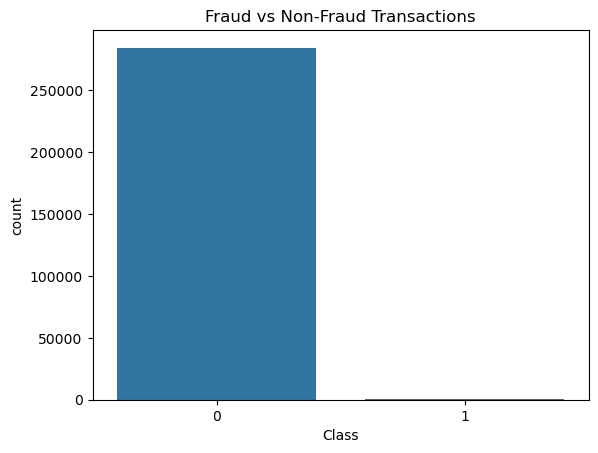

In [10]:
sns.countplot(x='Class', data=data)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()


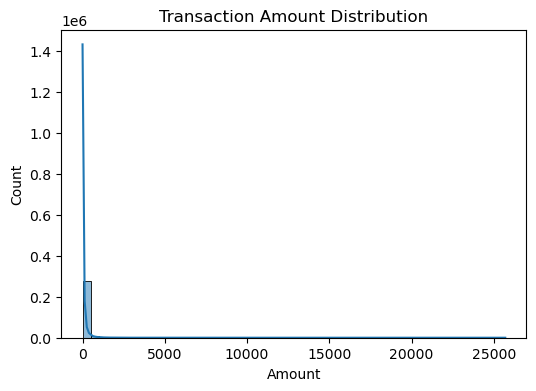

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(data['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()


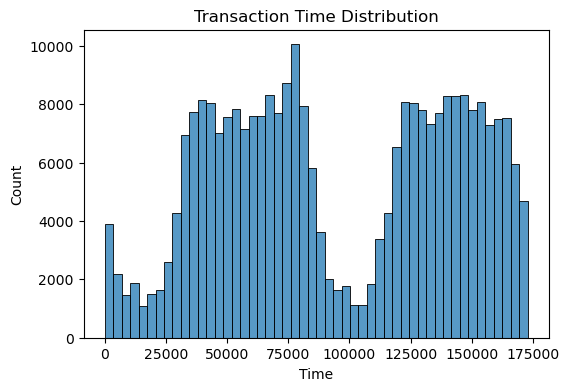

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(data['Time'], bins=50)
plt.title("Transaction Time Distribution")
plt.show()


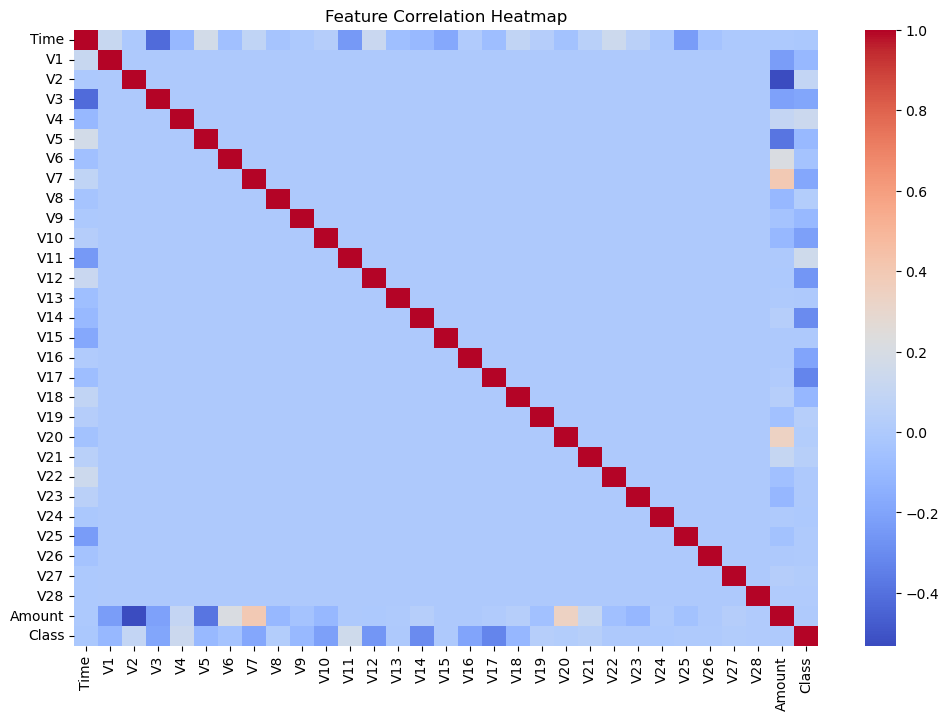

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


In [14]:
data.corr()['Class'].sort_values(ascending=False)


Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve)
import joblib
from imblearn.over_sampling import SMOTE   


# separation of the x(feature) and y(target=class)

In [16]:
df = pd.read_csv('../data/raw/creditcard.csv')  
X = df.drop('Class', axis=1)
y = df['Class']


In [17]:
time_threshold = df['Time'].quantile(0.80)   
train_idx = df['Time'] < time_threshold
test_idx = df['Time'] >= time_threshold

X_train = X[train_idx].drop('Time', axis=1)  
X_test  = X[test_idx].drop('Time', axis=1)
y_train = y[train_idx]
y_test  = y[test_idx]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (227845, 29) Test shape: (56962, 29)


In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test  = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

joblib.dump(scaler, '../models/scaler.pkl')


['../models/scaler.pkl']

In [19]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)


In [20]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)       # or use X_train_res, y_train_res if SMOTE used
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:,1]


In [21]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)       # or X_train_res, y_train_res
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]


In [22]:
def eval_report(y_true, y_pred, y_proba=None):
    print(classification_report(y_true, y_pred, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)
    if y_proba is not None:
        print("ROC-AUC:", roc_auc_score(y_true, y_proba))

print("Logistic Regression:")
eval_report(y_test, y_pred_lr, y_proba_lr)

print("\nRandom Forest:")
eval_report(y_test, y_pred_rf, y_proba_rf)


Logistic Regression:
              precision    recall  f1-score   support

           0     0.9999    0.9741    0.9868     56887
           1     0.0441    0.9067    0.0842        75

    accuracy                         0.9740     56962
   macro avg     0.5220    0.9404    0.5355     56962
weighted avg     0.9986    0.9740    0.9856     56962

Confusion Matrix:
 [[55414  1473]
 [    7    68]]
ROC-AUC: 0.9863208348714703

Random Forest:
              precision    recall  f1-score   support

           0     0.9996    1.0000    0.9998     56887
           1     0.9804    0.6667    0.7937        75

    accuracy                         0.9995     56962
   macro avg     0.9900    0.8333    0.8967     56962
weighted avg     0.9995    0.9995    0.9995     56962

Confusion Matrix:
 [[56886     1]
 [   25    50]]
ROC-AUC: 0.9446475761890532


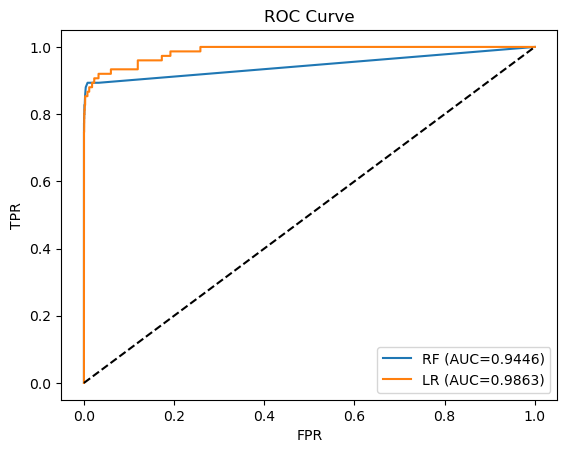

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr, tpr, label=f'RF (AUC={roc_auc_score(y_test,y_proba_rf):.4f})')
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr, tpr, label=f'LR (AUC={roc_auc_score(y_test,y_proba_lr):.4f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend(); plt.show()


In [24]:
thresholds = np.linspace(0.01, 0.9, 90)
best = {'thr': None, 'recall':0, 'precision':0, 'f1':0}
for thr in thresholds:
    yp = (y_proba_rf > thr).astype(int)
    r = recall_score(y_test, yp)
    p = precision_score(y_test, yp, zero_division=0)
    f = f1_score(y_test, yp, zero_division=0)
    if r >= 0.80 and f > best['f1']:  
        best.update({'thr': thr, 'recall': r, 'precision': p, 'f1': f})

print("Best threshold found:", best)


Best threshold found: {'thr': np.float64(0.05), 'recall': 0.8, 'precision': 0.6122448979591837, 'f1': 0.6936416184971098}


# feature importance

In [25]:
# randomforest
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.head(10)


V10    0.152938
V14    0.146565
V12    0.113674
V4     0.105876
V17    0.086832
V11    0.070330
V16    0.044836
V7     0.042143
V3     0.033242
V2     0.020184
dtype: float64

In [26]:
#logisticregression
coef = pd.Series(lr.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False).head(10)
coef


Amount    1.973362
V14      -1.147814
V4        1.112719
V1        1.094932
V12      -1.063585
V2        0.969990
V5        0.831889
V10      -0.830853
V6       -0.717339
V20      -0.715858
dtype: float64

In [27]:
joblib.dump(rf, '../models/random_forest_model.pkl')
joblib.dump(lr, '../models/logistic_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')


['../models/scaler.pkl']

# day-4

In [28]:
'''Train a machine learning model

Predict whether a transaction is fraud (1) or not fraud (0)

Evaluate how well the model performs'''

'Train a machine learning model\n\nPredict whether a transaction is fraud (1) or not fraud (0)\n\nEvaluate how well the model performs'

In [29]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler



In [30]:
X_train = X[X['Time'] < 100000]
X_test = X[X['Time'] >= 100000]

y_train = y[X['Time'] < 100000]
y_test = y[X['Time'] >= 100000]
#best  for training data

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [32]:
model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    solver='lbfgs'
)

model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [33]:
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.94      0.97    130887
           1       0.02      0.90      0.03       162

    accuracy                           0.94    131049
   macro avg       0.51      0.92      0.50    131049
weighted avg       1.00      0.94      0.97    131049



In [34]:
print(confusion_matrix(y_test, y_pred))

[[122592   8295]
 [    16    146]]


In [35]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9365809735289854


# day-5

In [36]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score
)


In [37]:

y_prob = model.predict_proba(X_test_scaled)[:, 1]


In [38]:
import numpy as np

for t in [0.3, 0.5, 0.7, 0.8, 0.9]:
    y_pred_t = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(confusion_matrix(y_test, y_pred_t))



Threshold: 0.3
[[113720  17167]
 [    10    152]]

Threshold: 0.5
[[122592   8295]
 [    16    146]]

Threshold: 0.7
[[127209   3678]
 [    18    144]]

Threshold: 0.8
[[128591   2296]
 [    19    143]]

Threshold: 0.9
[[129727   1160]
 [    22    140]]


In [39]:
threshold = 0.7
y_pred_custom = (y_prob >= threshold).astype(int)


In [40]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred_custom)


array([[127209,   3678],
       [    18,    144]])

In [41]:
precision = precision_score(y_test, y_pred_custom)
print("Precision:", precision)


Precision: 0.03767660910518053


In [42]:
recall = recall_score(y_test, y_pred_custom)
print("Recall:", recall)


Recall: 0.8888888888888888


In [43]:
print(classification_report(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       1.00      0.97      0.99    130887
           1       0.04      0.89      0.07       162

    accuracy                           0.97    131049
   macro avg       0.52      0.93      0.53    131049
weighted avg       1.00      0.97      0.98    131049



In [44]:
y_pred_default = model.predict(X_test_scaled)

print("Default Threshold Confusion Matrix")
print(confusion_matrix(y_test, y_pred_default))

print("Custom Threshold Confusion Matrix")
print(confusion_matrix(y_test, y_pred_custom))


Default Threshold Confusion Matrix
[[122592   8295]
 [    16    146]]
Custom Threshold Confusion Matrix
[[127209   3678]
 [    18    144]]


# day-6

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability for the fraud class (class = 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ROC & AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)


AUC Score: 0.9699476893035714


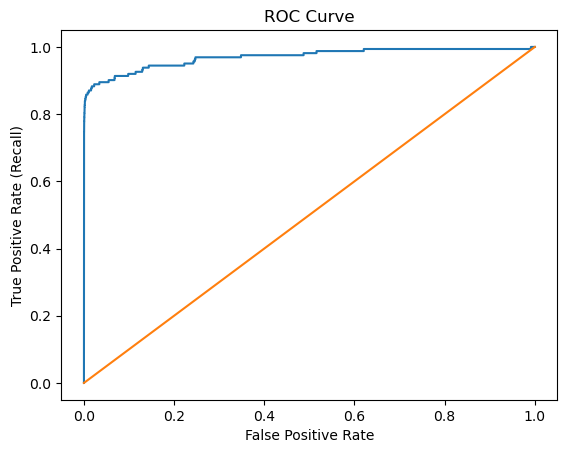

In [46]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.show()


In [47]:
j_scores = tpr - fpr
best_index = j_scores.argmax()
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)


Best Threshold: 0.7487089970485948


In [48]:
y_pred_roc = (y_prob >= best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_roc))
print(classification_report(y_test, y_pred_roc))


[[127919   2968]
 [    18    144]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    130887
           1       0.05      0.89      0.09       162

    accuracy                           0.98    131049
   macro avg       0.52      0.93      0.54    131049
weighted avg       1.00      0.98      0.99    131049



# day-7

In [49]:
baseline_model = LogisticRegression(
    max_iter=5000,
    solver='lbfgs'
)
baseline_model.fit(X_train_scaled, y_train)
# without class

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [50]:
from sklearn.linear_model import LogisticRegression

weighted_model = LogisticRegression(
    class_weight={0: 1, 1: 5},
    max_iter=5000,
    solver='lbfgs'
)

weighted_model.fit(X_train_scaled, y_train)
# with class

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,"{0: 1, 1: 5}"
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [51]:
y_prob_base = baseline_model.predict_proba(X_test_scaled)[:, 1]
y_prob_weighted = weighted_model.predict_proba(X_test_scaled)[:, 1]


In [52]:
y_pred_base = (y_prob_base >= best_threshold).astype(int)
y_pred_weighted = (y_prob_weighted >= best_threshold).astype(int)


In [53]:
from sklearn.metrics import confusion_matrix, classification_report

print("Class-Weighted Model")
print(confusion_matrix(y_test, y_pred_weighted))
print(classification_report(y_test, y_pred_weighted))


Class-Weighted Model
[[130836     51]
 [    39    123]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    130887
           1       0.71      0.76      0.73       162

    accuracy                           1.00    131049
   macro avg       0.85      0.88      0.87    131049
weighted avg       1.00      1.00      1.00    131049



In [54]:
print("Baseline Model")
print(confusion_matrix(y_test, y_pred_base))

print("Class-Weighted Model")
print(confusion_matrix(y_test, y_pred_weighted))


Baseline Model
[[130844     43]
 [    72     90]]
Class-Weighted Model
[[130836     51]
 [    39    123]]


In [55]:
from sklearn.metrics import recall_score

print("Baseline Recall:", recall_score(y_test, y_pred_base))
print("Weighted Recall:", recall_score(y_test, y_pred_weighted))


Baseline Recall: 0.5555555555555556
Weighted Recall: 0.7592592592592593


# day-8

In [56]:
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

base_model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [57]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    base_model,
    method='isotonic',   # better for fraud data
    cv=3
)

calibrated_model.fit(X_train_scaled, y_train)


,estimator,LogisticRegre...max_iter=1000)
,method,'isotonic'
,cv,3
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1


In [58]:
y_prob_before = base_model.predict_proba(X_test_scaled)[:, 1]
y_prob_after = calibrated_model.predict_proba(X_test_scaled)[:, 1]


In [59]:
from sklearn.metrics import average_precision_score

pr_auc_before = average_precision_score(y_test, y_prob_before)
pr_auc_after = average_precision_score(y_test, y_prob_after)

print("PR-AUC Before Calibration:", pr_auc_before)
print("PR-AUC After Calibration :", pr_auc_after)


PR-AUC Before Calibration: 0.7599027400351749
PR-AUC After Calibration : 0.7585450325275025


In [60]:
y_pred_final = (y_prob_after >= 0.5).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_final))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    130887
           1       0.80      0.73      0.77       162

    accuracy                           1.00    131049
   macro avg       0.90      0.87      0.88    131049
weighted avg       1.00      1.00      1.00    131049



In [61]:
# Predict calibrated probabilities
y_prob_calibrated = calibrated_model.predict_proba(X_test_scaled)[:, 1]


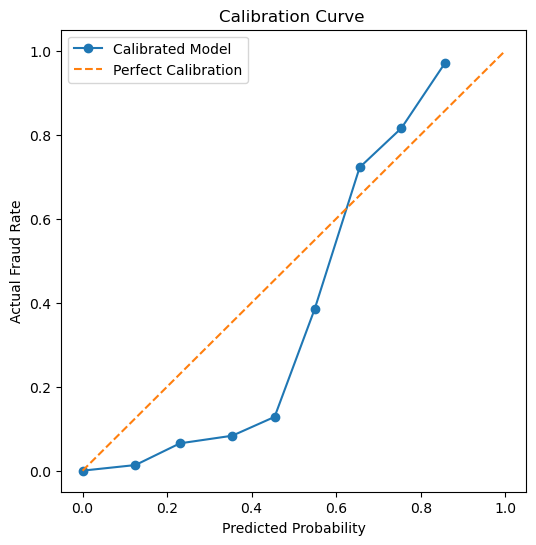

In [62]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test, 
    y_prob_calibrated, 
    n_bins=10
)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibrated Model')
plt.plot([0,1], [0,1], linestyle='--', label='Perfect Calibration')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Fraud Rate")
plt.title("Calibration Curve ")
plt.legend()
plt.show()


In [63]:
import pandas as pd

risk_df = pd.DataFrame({
    'probability': y_prob_calibrated,
    'actual': y_test.values
})

risk_df['risk_band'] = pd.cut(
    risk_df['probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

risk_summary = risk_df.groupby('risk_band').agg(
    total_transactions=('actual', 'count'),
    fraud_cases=('actual', 'sum'),
)

risk_summary['fraud_rate'] = (
    risk_summary['fraud_cases'] / risk_summary['total_transactions']
)

print(risk_summary)


             total_transactions  fraud_cases  fraud_rate
risk_band                                               
Low Risk                 130767           36    0.000275
Medium Risk                  89           17    0.191011
High Risk                   123          109    0.886179


/var/folders/z_/rxtrq0xn3vs8rdmxpp6hx11c0000gn/T/ipykernel_2192/4183718111.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_summary = risk_df.groupby('risk_band').agg(


In [64]:
risk_summary


,total_transactions,fraud_cases,fraud_rate
risk_band,,,
Low Risk,130767,36,0.000275
Medium Risk,89,17,0.191011
High Risk,123,109,0.886179


# day-9

In [65]:
pip install shap


Note: you may need to restart the kernel to use updated packages.


In [66]:
# Take the first calibrated classifier
calibrated_clf = calibrated_model.calibrated_classifiers_[0].estimator


In [67]:
import shap
explainer = shap.Explainer(
    calibrated_clf,
    X_train_scaled
)

shap_values = explainer(X_test_scaled)


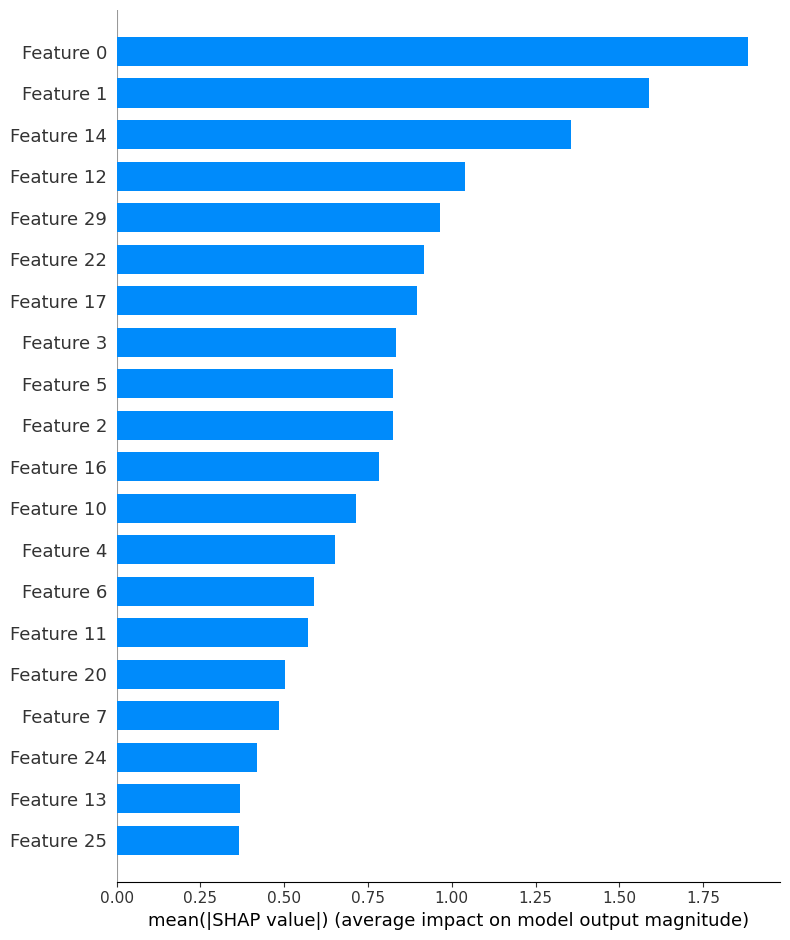

In [68]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)


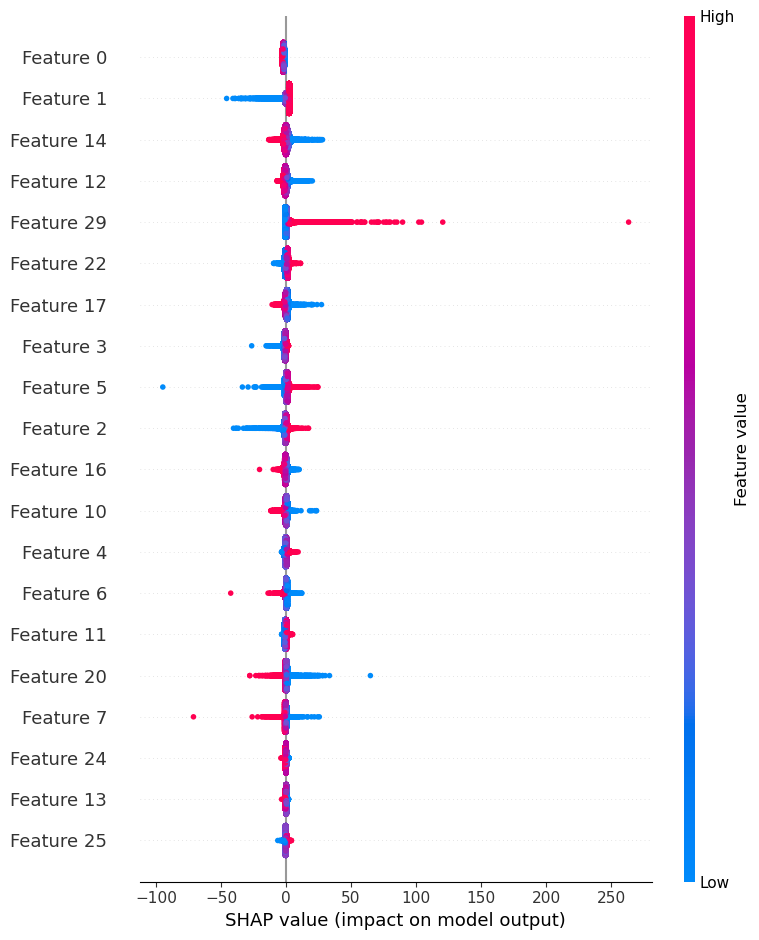

In [69]:
shap.summary_plot(
    shap_values,
    X_test
)


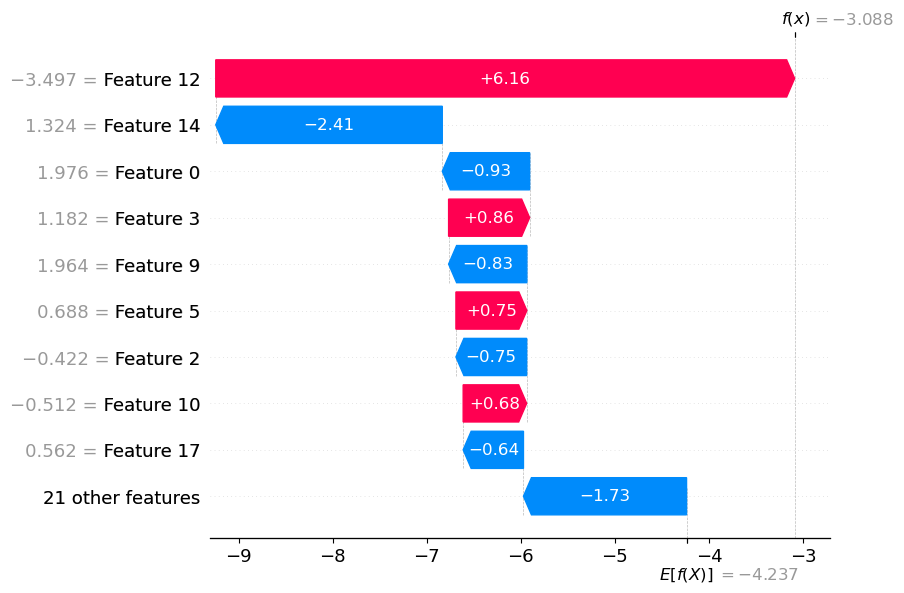

In [70]:
index = 3  # any fraud transaction index

shap.plots.waterfall(shap_values[index])


# day-10

In [71]:
import numpy as np
import pandas as pd

def calculate_psi(expected, actual, buckets=10):

    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))

    expected_perc = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_perc = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    psi = np.sum(
        (expected_perc - actual_perc) *
        np.log((expected_perc + 1e-10) / (actual_perc + 1e-10))
    )

    return psi


In [72]:
train_probs = model.predict_proba(X_train_scaled)[:, 1]
test_probs = model.predict_proba(X_test_scaled)[:, 1]


In [73]:
psi_value = calculate_psi(train_probs, test_probs)

print(f"PSI Score: {psi_value:.4f}")


PSI Score: 0.1293


In [74]:
def feature_psi(train_df, test_df, feature, buckets=10):
    return calculate_psi(
        train_df[feature].values,
        test_df[feature].values,
        buckets
    )

important_features = ['Amount', 'Time']

for feature in important_features:
    psi_val = feature_psi(X_train, X_test, feature)
    print(f"{feature} PSI: {psi_val:.4f}")


Amount PSI: 0.0008
Time PSI: 20.7233


# day-11

In [75]:
from sklearn.ensemble import RandomForestClassifier


In [76]:
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,12
,min_samples_split,50
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [77]:
# Always store probabilities
y_prob_train = final_model.predict_proba(X_train)[:, 1]
y_prob_test  = final_model.predict_proba(X_test)[:, 1]


In [78]:
baseline_threshold = 0.3
y_pred_baseline = (y_prob_test >= baseline_threshold).astype(int)

baseline_recall = recall_score(y_test, y_pred_baseline)
print("Baseline Fraud Recall:", baseline_recall)


Baseline Fraud Recall: 0.8271604938271605


In [79]:
import pandas as pd

psi_df = pd.DataFrame({
    "feature": ["V1", "V2", "V3"],
    "psi": [0.03, 0.18, 0.42]
})


In [80]:
def psi_alert(psi):
    if psi > 0.25:
        return "CRITICAL"
    elif psi > 0.10:
        return "WARNING"
    else:
        return "STABLE"


In [81]:
psi_df["drift_status"] = psi_df["psi"].apply(psi_alert)
psi_df


,feature,psi,drift_status
0,V1,0.03,STABLE
1,V2,0.18,WARNING
2,V3,0.42,CRITICAL


In [82]:
data_drift_flag = any(psi_df["drift_status"] == "CRITICAL")

print("Data Drift Detected:", data_drift_flag)


Data Drift Detected: True


In [83]:
y_prob_current = final_model.predict_proba(X_test)[:, 1]
y_pred_current = (y_prob_current >= baseline_threshold).astype(int)

current_recall = recall_score(y_test, y_pred_current)

print("Current Fraud Recall:", current_recall)


Current Fraud Recall: 0.8271604938271605


In [84]:
def performance_alert(baseline, current):
    drop = baseline - current
    
    if drop > 0.10:
        return "CRITICAL"
    elif drop > 0.05:
        return "WARNING"
    else:
        return "STABLE"


In [85]:
performance_status = performance_alert(baseline_recall, current_recall)
print("Performance Status:", performance_status)


Performance Status: STABLE


In [86]:
if data_drift_flag or performance_status == "CRITICAL":
    retrain_decision = "RETRAIN MODEL"
elif performance_status == "WARNING":
    retrain_decision = "MONITOR CLOSELY"
else:
    retrain_decision = "MODEL STABLE"

print("Final Decision:", retrain_decision)


Final Decision: RETRAIN MODEL


# day-12


In [87]:
final_model
y_prob_test = final_model.predict_proba(X_test)[:, 1]


In [88]:
from sklearn.linear_model import LogisticRegression

cost_sensitive_model = LogisticRegression(
    class_weight={0: 1, 1: 20},   # fraud is more expensive
    max_iter=3000
)

cost_sensitive_model.fit(X_train, y_train)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,"{0: 1, 1: 20}"
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [89]:
from sklearn.metrics import confusion_matrix

y_pred_normal = final_model.predict(X_test)
y_pred_cost   = cost_sensitive_model.predict(X_test)

print("Normal Model @ 0.5")
print(confusion_matrix(y_test, y_pred_normal))

print("\nCost-Sensitive Model @ 0.5")
print(confusion_matrix(y_test, y_pred_cost))


Normal Model @ 0.5
[[130855     32]
 [    33    129]]

Cost-Sensitive Model @ 0.5
[[130706    181]
 [    29    133]]


In [90]:
selected_model = cost_sensitive_model


In [91]:
y_prob_test = selected_model.predict_proba(X_test)[:, 1]


In [92]:
FINAL_THRESHOLD = best_threshold

y_pred_final = (y_prob_test >= FINAL_THRESHOLD).astype(int)

print(confusion_matrix(y_test, y_pred_final))


[[130799     88]
 [    33    129]]


In [93]:
COST_FP = 500      # Genuine wrongly blocked
COST_FN = 50000   # Fraud missed


In [94]:
import numpy as np
from sklearn.metrics import confusion_matrix

thresholds = np.arange(0.05, 1.0, 0.05)

best_threshold = 0
min_cost = float("inf")

for t in thresholds:
    y_pred_t = (y_prob_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    total_cost = (fp * COST_FP) + (fn * COST_FN)
    
    print(f"Threshold {t:.2f} → Cost = ₹{total_cost:,}")
    
    if total_cost < min_cost:
        min_cost = total_cost
        best_threshold = t

print("\nBest Threshold:", best_threshold)
print("Minimum Business Cost:", min_cost)


Threshold 0.05 → Cost = ₹3,137,500
Threshold 0.10 → Cost = ₹1,840,500
Threshold 0.15 → Cost = ₹1,594,500
Threshold 0.20 → Cost = ₹1,472,500
Threshold 0.25 → Cost = ₹1,507,500
Threshold 0.30 → Cost = ₹1,520,500
Threshold 0.35 → Cost = ₹1,493,000
Threshold 0.40 → Cost = ₹1,473,500
Threshold 0.45 → Cost = ₹1,457,500
Threshold 0.50 → Cost = ₹1,540,500
Threshold 0.55 → Cost = ₹1,525,500
Threshold 0.60 → Cost = ₹1,517,000
Threshold 0.65 → Cost = ₹1,559,000
Threshold 0.70 → Cost = ₹1,702,000
Threshold 0.75 → Cost = ₹1,694,000
Threshold 0.80 → Cost = ₹1,785,500
Threshold 0.85 → Cost = ₹1,828,000
Threshold 0.90 → Cost = ₹1,924,000
Threshold 0.95 → Cost = ₹2,422,000

Best Threshold: 0.45
Minimum Business Cost: 1457500


In [95]:
# Baseline model @ 0.5
y_pred_base = (final_model.predict_proba(X_test)[:,1] >= 0.5).astype(int)
tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_test, y_pred_base).ravel()

baseline_cost = fp_b*COST_FP + fn_b*COST_FN
optimized_cost = min_cost

print("Baseline Cost:", baseline_cost)
print("Optimized Cost:", optimized_cost)
print("Business Savings:", baseline_cost - optimized_cost)


Baseline Cost: 1666000
Optimized Cost: 1457500
Business Savings: 208500


In [96]:
# using this as the final threshold for all
FINAL_THRESHOLD = 0.20

y_pred_final = (y_prob_test >= FINAL_THRESHOLD).astype(int)


In [97]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))


[[130342    545]
 [    24    138]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    130887
           1       0.20      0.85      0.33       162

    accuracy                           1.00    131049
   macro avg       0.60      0.92      0.66    131049
weighted avg       1.00      1.00      1.00    131049



In [98]:
def fraud_decision(prob): 
    if prob >= 0.8:
        return "Block"
    elif prob >= 0.20:
        return "Manual Review"
    else:
        return "Allow"


In [99]:
print(fraud_decision(0.85))
print(fraud_decision(0.3))
print(fraud_decision(0.1))


Block
Manual Review
Allow


# day -13

In [100]:
# Reference (baseline period)
risk_score_ref = final_model.predict_proba(X_train)[:, 1] * 100

# Current (production simulation)
risk_score_cur = final_model.predict_proba(X_test)[:, 1] * 100

print("Reference Risk Score Sample:", risk_score_ref[:10])
print("Current Risk Score Sample:", risk_score_cur[:10])


Reference Risk Score Sample: [1.37444737 0.00781849 2.86899429 0.03894145 0.13825839 0.00781849
 0.06945889 0.89337871 0.04831485 0.08200932]
Current Risk Score Sample: [1.51025222 0.05401677 0.15680898 0.13045756 1.10330867 2.46336232
 8.93725727 0.07615487 4.37496342 0.13176979]


In [101]:
bins = [0, 30, 70, 100]

ref_dist = np.histogram(risk_score_ref, bins=bins)[0] / len(risk_score_ref)
cur_dist = np.histogram(risk_score_cur, bins=bins)[0] / len(risk_score_cur)

print("\nReference Distribution (Low, Med, High):", ref_dist)
print("Current Distribution   (Low, Med, High):", cur_dist)



Reference Distribution (Low, Med, High): [9.97170879e-01 5.91839124e-04 2.23728196e-03]
Current Distribution   (Low, Med, High): [0.99780998 0.00117513 0.00101489]


In [102]:
def calculate_psi(expected, actual):
    expected = np.array(expected)
    actual = np.array(actual)

    expected = np.where(expected == 0, 0.0001, expected)
    actual   = np.where(actual == 0, 0.0001, actual)

    psi = np.sum((actual - expected) * np.log(actual / expected))
    return psi


In [103]:
risk_score_psi = calculate_psi(ref_dist, cur_dist)

print("\nRisk Score PSI:", round(risk_score_psi, 4))



Risk Score PSI: 0.0014


In [104]:
if risk_score_psi < 0.1:
    status = "Stable"
elif risk_score_psi < 0.25:
    status = "Moderate Shift"
else:
    status = "Severe Shift"

print("PSI Status:", status)



PSI Status: Stable


# day-14


In [105]:
def decision_bucket(score):
    if score < 0.3:
        return "Approve"
    elif score < 0.7:
        return "Review"
    else:
        return "Block"


In [106]:
y_prob = final_model.predict_proba(X_test)[:, 1]

decision_df = pd.DataFrame({
    "risk_score": y_prob,
    "decision": [decision_bucket(s) for s in y_prob],
    "actual_label": y_test.values
})

decision_df.head()



,risk_score,decision,actual_label
0,0.015103,Approve,0
1,0.000540,Approve,0
2,0.001568,Approve,0
3,0.001305,Approve,0
4,0.011033,Approve,0


In [109]:
# decision monitoring
decision_rate = (
    decision_df["decision"]
    .value_counts(normalize=True)
    .reset_index()
)

decision_rate.columns = ["decision", "rate"]
decision_rate


,decision,rate
0,Approve,0.997810
1,Review,0.001175
2,Block,0.001015


In [110]:
# outcome monitoring
outcome_summary = (
    decision_df
    .groupby("decision")
    .agg(
        total_cases=("actual_label", "count"),
        fraud_cases=("actual_label", "sum")
    )
    .reset_index()
)

outcome_summary


,decision,total_cases,fraud_cases
0,Approve,130762,28
1,Block,133,119
2,Review,154,15


In [111]:
COST_FP = 1      # customer friction
COST_FN = 10     # fraud loss
COST_REVIEW = 3 # manual review cost


In [112]:
decision_df["cost"] = 0

# Approved but fraud → FN
decision_df.loc[
    (decision_df["decision"] == "Approve") &
    (decision_df["actual_label"] == 1),
    "cost"
] = COST_FN

# Review cost
decision_df.loc[
    decision_df["decision"] == "Review",
    "cost"
] = COST_REVIEW

# Block but not fraud → FP
decision_df.loc[
    (decision_df["decision"] == "Block") &
    (decision_df["actual_label"] == 0),
    "cost"
] = COST_FP

total_cost = decision_df["cost"].sum()
total_cost


np.int64(756)